# Taller 05 - Aprendizaje Supervisado: Clasificación

## Predicción de entregas E-Commerce

### Objetivo

El objetivo de este proyecto es desarrollar un modelo de aprendizaje
supervisado que permita predecir si un envío llegará a tiempo o tendrá retraso.

Para esto se realizará exploración de datos, tratamiento de variables
categóricas, escalamiento de variables numéricas y entrenamiento de modelos
de clasificación.

In [1]:
import pandas as pd

df = pd.read_csv("Train.csv")

df.head()

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1
3,4,B,Flight,3,3,176,4,medium,M,10,1177,1
4,5,C,Flight,2,2,184,3,medium,F,46,2484,1


In [2]:

# Modelos de clasificación
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# División de datos
from sklearn.model_selection import train_test_split

# Escalamiento
from sklearn.preprocessing import StandardScaler

# Métricas de evaluación
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

In [ ]:
# Paso 1: Usar pandas para cargar el dataset descargado de Kaggle

In [14]:
df = pd.read_csv("Train.csv")

df.head()

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1
3,4,B,Flight,3,3,176,4,medium,M,10,1177,1
4,5,C,Flight,2,2,184,3,medium,F,46,2484,1


Tamaña Dataset

In [4]:
df.shape

(10999, 12)

Revisar Información

Tipo de datos
Columnas
Valores faltantes

In [5]:
df.isnull().sum()

ID                     0
Warehouse_block        0
Mode_of_Shipment       0
Customer_care_calls    0
Customer_rating        0
Cost_of_the_Product    0
Prior_purchases        0
Product_importance     0
Gender                 0
Discount_offered       0
Weight_in_gms          0
Reached.on.Time_Y.N    0
dtype: int64

Reprocesamiento

Columnas

In [6]:
df.columns

Index(['ID', 'Warehouse_block', 'Mode_of_Shipment', 'Customer_care_calls',
       'Customer_rating', 'Cost_of_the_Product', 'Prior_purchases',
       'Product_importance', 'Gender', 'Discount_offered', 'Weight_in_gms',
       'Reached.on.Time_Y.N'],
      dtype='str')

## 2. Preprocesamiento de datos e Ingeniería de características

En esta etapa se realiza la preparación de los datos para que puedan ser utilizados por los modelos de Machine Learning.

Los algoritmos de aprendizaje supervisado trabajan con valores numéricos, por lo que es necesario transformar las variables categóricas (variables que contienen texto) en formatos que los modelos puedan interpretar.

Para este proceso se aplican dos técnicas:

- Codificación ordinal (Ordinal Encoding) para variables que tienen un orden lógico entre sus categorías.
- One-Hot Encoding para variables categóricas que no presentan una jerarquía definida.
Variable Categorica, Crear nuevo Dataset con nuevas categorias

low → baja importancia
medium → importancia media
high → alta importancia

low = 1
medium = 2
high = 3

In [15]:
df["Product_importance"].head()

0       low
1       low
2       low
3    medium
4    medium
Name: Product_importance, dtype: str

### Transformación de la variable Product_importance

La variable Product_importance representa el nivel de importancia del producto dentro del envío.

Esta variable tiene un orden natural:

Low < Medium < High

Por esta razón se aplica una codificación ordinal, asignando valores numéricos que conservan dicha jerarquía:

- Low = 1
- Medium = 2
- High = 3

Esta transformación permite que el modelo pueda interpretar que existe una diferencia de importancia entre las categorías.

In [16]:
df["Product_importance"] = df["Product_importance"].map({
    "low": 1,
    "medium": 2,
    "high": 3
})

In [17]:
df["Product_importance"].head()

0    1
1    1
2    1
3    2
4    2
Name: Product_importance, dtype: int64

### Transformación de la variable Mode_of_Shipment

La variable Mode_of_Shipment indica el medio utilizado para realizar el envío.

Sus categorías son:

- Flight (avión)
- Ship (barco)
- Road (carretera)

Estas categorías no tienen un orden o jerarquía entre ellas, por lo que no es adecuado asignar valores numéricos directamente.

Para evitar que el modelo interprete una categoría como superior a otra, se utiliza la técnica One-Hot Encoding, la cual crea nuevas columnas binarias representadas con valores 0 y 1.


In [18]:
df["Mode_of_Shipment"].unique()

<StringArray>
['Flight', 'Ship', 'Road']
Length: 3, dtype: str

In [20]:
df = pd.get_dummies(
    df,
    columns=["Mode_of_Shipment"],
    drop_first=True
)

In [21]:
df["Warehouse_block"].unique()

<StringArray>
['D', 'F', 'A', 'B', 'C']
Length: 5, dtype: str

### Transformación de la variable Warehouse_block

La variable Warehouse_block identifica el bloque de almacenamiento donde se procesa cada envío.

Sus categorías corresponden a diferentes almacenes:

A, B, C, D y F.

Estas categorías no presentan un orden lógico o jerarquía, por lo tanto no se aplica codificación ordinal.

Se utiliza One-Hot Encoding para transformar cada categoría en una variable numérica binaria (0 y 1), permitiendo que los modelos de Machine Learning puedan procesar esta información sin crear relaciones de orden incorrectas.

In [24]:
df = pd.get_dummies(
    df,
    columns=["Warehouse_block"],
    drop_first=True
)

KeyError: "None of [Index(['Warehouse_block'], dtype='str')] are in the [columns]"

In [25]:
df.head()

,ID,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N,Mode_of_Shipment_Road,Mode_of_Shipment_Ship,Warehouse_block_B,Warehouse_block_C,Warehouse_block_D,Warehouse_block_F
0,1,4,2,177,3,1,F,44,1233,1,False,False,False,False,True,False
1,2,4,5,216,2,1,M,59,3088,1,False,False,False,False,False,True
2,3,2,2,183,4,1,M,48,3374,1,False,False,False,False,False,False
3,4,3,3,176,4,2,M,10,1177,1,False,False,True,False,False,False
4,5,2,2,184,3,2,F,46,2484,1,False,False,False,True,False,False


In [26]:
df.columns

Index(['ID', 'Customer_care_calls', 'Customer_rating', 'Cost_of_the_Product',
       'Prior_purchases', 'Product_importance', 'Gender', 'Discount_offered',
       'Weight_in_gms', 'Reached.on.Time_Y.N', 'Mode_of_Shipment_Road',
       'Mode_of_Shipment_Ship', 'Warehouse_block_B', 'Warehouse_block_C',
       'Warehouse_block_D', 'Warehouse_block_F'],
      dtype='str')

### Eliminación de variables no predictivas

La columna ID corresponde únicamente a un identificador único de cada registro.

Esta variable no contiene información relacionada con las características del envío, por lo que no aporta valor predictivo al modelo.

Por esta razón se elimina antes de realizar el entrenamiento.

In [27]:
df.drop("ID", axis=1, inplace=True)

### Separación de variables predictoras y variable objetivo

En aprendizaje supervisado se deben separar los datos en:

- X: conjunto de variables independientes o características que utiliza el modelo para aprender.
- y: variable objetivo que representa el resultado que queremos predecir.

Para este proyecto, la variable objetivo será Reached.on.Time_Y.N, que indica si el envío llegó a tiempo o no.

In [28]:
X = df.drop("Reached.on.Time_Y.N", axis=1)

y = df["Reached.on.Time_Y.N"]

In [29]:
X.head()

,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Mode_of_Shipment_Road,Mode_of_Shipment_Ship,Warehouse_block_B,Warehouse_block_C,Warehouse_block_D,Warehouse_block_F
0,4,2,177,3,1,F,44,1233,False,False,False,False,True,False
1,4,5,216,2,1,M,59,3088,False,False,False,False,False,True
2,2,2,183,4,1,M,48,3374,False,False,False,False,False,False
3,3,3,176,4,2,M,10,1177,False,False,True,False,False,False
4,2,2,184,3,2,F,46,2484,False,False,False,True,False,False


In [30]:
y.head()

0    1
1    1
2    1
3    1
4    1
Name: Reached.on.Time_Y.N, dtype: int64

### Verificación de variables predictoras

Después del proceso de limpieza y transformación, las variables categóricas fueron convertidas a formato numérico mediante técnicas de codificación.

La matriz de características X contiene únicamente las variables que serán utilizadas por los modelos de clasificación, mientras que la variable objetivo fue separada para evaluar la capacidad predictiva del algoritmo.

Las variables categóricas transformadas ahora pueden ser interpretadas por los modelos de Machine Learning.

In [31]:
y.value_counts()

Reached.on.Time_Y.N
1    6563
0    4436
Name: count, dtype: int64

### Análisis de la variable objetivo

La variable objetivo del modelo corresponde a `Reached.on.Time_Y.N`, la cual indica si un envío llegó a tiempo o presentó retraso.

Para el problema de clasificación se definieron:

- **X (variables predictoras):** contiene las características del envío que pueden influir en el resultado, como llamadas de atención al cliente, calificación del cliente, costo del producto, peso, importancia del producto, medio de transporte y bloque de almacenamiento.

- **y (variable objetivo):** contiene la etiqueta que el modelo debe aprender a predecir:
    - 0: envío entregado a tiempo.
    - 1: envío con retraso.

Al separar estas variables se prepara la información para entrenar un modelo de aprendizaje supervisado, donde el algoritmo aprenderá la relación entre las características del envío y la probabilidad de retraso.

In [32]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 10999 entries, 0 to 10998
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   Customer_care_calls    10999 non-null  int64
 1   Customer_rating        10999 non-null  int64
 2   Cost_of_the_Product    10999 non-null  int64
 3   Prior_purchases        10999 non-null  int64
 4   Product_importance     10999 non-null  int64
 5   Gender                 10999 non-null  str  
 6   Discount_offered       10999 non-null  int64
 7   Weight_in_gms          10999 non-null  int64
 8   Mode_of_Shipment_Road  10999 non-null  bool 
 9   Mode_of_Shipment_Ship  10999 non-null  bool 
 10  Warehouse_block_B      10999 non-null  bool 
 11  Warehouse_block_C      10999 non-null  bool 
 12  Warehouse_block_D      10999 non-null  bool 
 13  Warehouse_block_F      10999 non-null  bool 
dtypes: bool(6), int64(7), str(1)
memory usage: 752.0 KB


### Tratamiento de la variable Gender

Durante la revisión de tipos de datos se identificó que la variable Gender aún se encuentra en formato texto.

Los modelos de Machine Learning requieren variables numéricas, por lo que esta variable será transformada utilizando una codificación binaria.

Se asignará un valor numérico para representar cada categoría sin generar una relación de orden entre ellas.

In [33]:
X["Gender"] = X["Gender"].map({
    "M":1,
    "F":0
})

In [34]:
X.head()

,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Mode_of_Shipment_Road,Mode_of_Shipment_Ship,Warehouse_block_B,Warehouse_block_C,Warehouse_block_D,Warehouse_block_F
0,4,2,177,3,1,0,44,1233,False,False,False,False,True,False
1,4,5,216,2,1,1,59,3088,False,False,False,False,False,True
2,2,2,183,4,1,1,48,3374,False,False,False,False,False,False
3,3,3,176,4,2,1,10,1177,False,False,True,False,False,False
4,2,2,184,3,2,0,46,2484,False,False,False,True,False,False


In [35]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 10999 entries, 0 to 10998
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   Customer_care_calls    10999 non-null  int64
 1   Customer_rating        10999 non-null  int64
 2   Cost_of_the_Product    10999 non-null  int64
 3   Prior_purchases        10999 non-null  int64
 4   Product_importance     10999 non-null  int64
 5   Gender                 10999 non-null  int64
 6   Discount_offered       10999 non-null  int64
 7   Weight_in_gms          10999 non-null  int64
 8   Mode_of_Shipment_Road  10999 non-null  bool 
 9   Mode_of_Shipment_Ship  10999 non-null  bool 
 10  Warehouse_block_B      10999 non-null  bool 
 11  Warehouse_block_C      10999 non-null  bool 
 12  Warehouse_block_D      10999 non-null  bool 
 13  Warehouse_block_F      10999 non-null  bool 
dtypes: bool(6), int64(8)
memory usage: 752.0 KB


### Verificación final del formato de variables

Después del proceso de transformación de variables categóricas, se verificó nuevamente la estructura del conjunto de datos.

Inicialmente algunas variables se encontraban en formato texto, lo que impedía que fueran utilizadas directamente por los algoritmos de Machine Learning.

Se realizaron las siguientes transformaciones:

- `Product_importance`: se convirtió mediante codificación ordinal, conservando la jerarquía entre sus categorías.
- `Mode_of_Shipment` y `Warehouse_block`: se transformaron mediante One-Hot Encoding, generando variables binarias.
- `Gender`: se convirtió a formato numérico mediante una codificación binaria.

Como resultado, todas las variables predictoras quedaron en formato numérico, listas para aplicar técnicas de escalamiento y posteriormente entrenar los modelos de clasificación.

## Escalamiento de variables numéricas

El escalamiento de variables es una etapa de preprocesamiento que permite llevar las variables numéricas a una escala común.

Esto evita que variables con valores más grandes tengan una influencia desproporcionada sobre el modelo debido únicamente a su magnitud.

Para este proyecto se utilizará StandardScaler de Scikit-learn, el cual transforma los datos considerando la media y la desviación estándar de cada variable.

In [36]:
from sklearn.preprocessing import StandardScaler

### Resultado del escalamiento de variables

Después de aplicar StandardScaler, las variables numéricas fueron transformadas a una escala común.

Los valores resultantes representan la distancia de cada observación respecto al promedio de la variable, expresada en desviaciones estándar.

Los valores cercanos a 0 representan datos cercanos a la media, mientras que valores positivos o negativos indican observaciones por encima o por debajo del promedio.

Este proceso permite que los modelos de clasificación trabajen con variables comparables y evita que una característica tenga mayor influencia únicamente por tener valores numéricos más grandes.

In [37]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [38]:
X_scaled[:5]

array([[-0.04771132, -0.7007551 , -0.69072171, -0.37273475, -0.94257564,
        -0.99176046,  1.88998336, -1.46823975, -0.4364594 , -1.45247977,
        -0.4471892 , -0.4471892 ,  2.23545828, -0.70705857],
       [-0.04771132,  1.42157771,  0.12074558, -1.02942377, -0.94257564,
         1.00830799,  2.81563557, -0.33389333, -0.4364594 , -1.45247977,
        -0.4471892 , -0.4471892 , -0.44733557,  1.41431   ],
       [-1.79988745, -0.7007551 , -0.56588059,  0.28395426, -0.94257564,
         1.00830799,  2.13682395, -0.15900218, -0.4364594 , -1.45247977,
        -0.4471892 , -0.4471892 , -0.44733557, -0.70705857],
       [-0.92379938,  0.00668917, -0.71152856,  0.28395426,  0.61643029,
         1.00830799, -0.20816164, -1.50248417, -0.4364594 , -1.45247977,
         2.23618996, -0.4471892 , -0.44733557, -0.70705857],
       [-1.79988745, -0.7007551 , -0.54507373, -0.37273475,  0.61643029,
        -0.99176046,  2.01340366, -0.70324386, -0.4364594 , -1.45247977,
        -0.4471892 ,  2.23

## División del conjunto de datos

Para entrenar y evaluar los modelos de clasificación se divide el dataset en dos grupos:

- Datos de entrenamiento (Train): utilizados por el modelo para aprender patrones.
- Datos de prueba (Test): utilizados para evaluar el rendimiento del modelo con datos no utilizados durante el entrenamiento.

Se utiliza una proporción del 80% para entrenamiento y 20% para prueba, además de un valor fijo de random_state para garantizar que los resultados puedan reproducirse.

In [40]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

In [41]:
X_train.shape
X_test.shape

(2200, 14)

2200 filas → tenemos 2200 envíos reservados para probar el modelo.
14 columnas → cada envío tiene 14 características o variables predictoras

In [43]:
X_train.shape

(8799, 14)

80% de 10999 registros ≈ 8799 para entrenamiento.
20% de 10999 registros = 2200 para prueba.

### Resultado de la división del dataset

El conjunto de datos fue dividido en dos grupos utilizando una proporción del 80% para entrenamiento y 20% para prueba.

El conjunto de entrenamiento será utilizado por los modelos para identificar patrones entre las variables predictoras y la variable objetivo.

El conjunto de prueba contiene datos que el modelo no ha visto previamente y permitirá evaluar su capacidad de generalización.

En este caso se obtuvieron:

- Datos de entrenamiento: 8799 registros aproximadamente.
- Datos de prueba: 2200 registros.

Cada registro conserva las 14 variables predictoras generadas después del proceso de transformación y escalamiento.

## Entrenamiento de modelos de clasificación

Para resolver el problema de predicción de retrasos en los envíos se entrenarán tres algoritmos de clasificación diferentes.

Los modelos seleccionados permitirán comparar diferentes enfoques de aprendizaje y determinar cuál presenta mejor capacidad predictiva.

Los modelos utilizados serán:

1. Regresión Logística: modelo base que permite establecer una referencia inicial de rendimiento.

2. Árbol de Decisión: modelo basado en reglas de decisión que permite identificar patrones dentro de los datos.

3. Random Forest: modelo ensamblado que combina múltiples árboles de decisión para mejorar la precisión y reducir errores.

In [44]:
X_train.shape

(8799, 14)

### Verificación de la división de datos

La división del dataset permitió separar la información disponible en dos conjuntos independientes.

El conjunto de entrenamiento contiene 8799 registros y será utilizado para que los modelos aprendan la relación entre las variables predictoras y la variable objetivo.

El conjunto de prueba contiene 2200 registros y será utilizado posteriormente para evaluar el desempeño de los modelos con datos que no fueron utilizados durante el entrenamiento.

Esta separación permite medir la capacidad de generalización del modelo y evitar evaluar su rendimiento únicamente con los datos utilizados para aprender.

## Selección de modelos de clasificación

Para comparar diferentes técnicas de aprendizaje supervisado se entrenarán tres modelos de clasificación:

- Regresión Logística.
- Árbol de Decisión.
- Random Forest.

Cada modelo será entrenado con los datos de entrenamiento y posteriormente evaluado utilizando el conjunto de prueba.

In [45]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [46]:
modelo_logistico = LogisticRegression(random_state=42)

modelo_arbol = DecisionTreeClassifier(random_state=42)

modelo_bosque = RandomForestClassifier(random_state=42)

In [47]:
modelo_logistico.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solve

### Modelo 1: Regresión Logística

La regresión logística es un modelo de clasificación utilizado como referencia inicial. Permite estimar la probabilidad de pertenecer a una categoría, en este caso determinar si un envío tendrá retraso o llegará a tiempo.

In [48]:
modelo_logistico.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solve

### Modelo 2: Árbol de Decisión

El árbol de decisión clasifica los datos mediante reglas generadas a partir de las características de los envíos. Su estructura permite identificar qué variables tienen mayor influencia en la predicción.

In [49]:
modelo_arbol.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

### Modelo 3: Random Forest

Random Forest es un modelo de aprendizaje basado en múltiples árboles de decisión. Combina las predicciones de varios árboles para mejorar la precisión y reducir el riesgo de sobreajuste.

In [50]:
modelo_bosque.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

Importar los modelos

In [53]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

Crear modelos

In [55]:
modelo_logistico = LogisticRegression(random_state=42)

modelo_arbol = DecisionTreeClassifier(random_state=42)

modelo_bosque = RandomForestClassifier(random_state=42)

In [56]:
modelo_logistico

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solve

In [57]:
modelo_arbol

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [58]:
modelo_bosque

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

Entrenar Modelo

In [59]:
modelo_logistico.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solve

In [60]:
modelo_arbol.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [61]:
modelo_bosque.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [62]:
modelo_bosque.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

## Predicción con los modelos entrenados

Después de entrenar los tres algoritmos de clasificación, se realizan predicciones utilizando el conjunto de prueba.

El objetivo es evaluar cómo se comportan los modelos con datos que no fueron utilizados durante el entrenamiento y medir su capacidad para generalizar nuevos casos.

In [63]:
pred_logistico = modelo_logistico.predict(X_test)

pred_arbol = modelo_arbol.predict(X_test)

pred_bosque = modelo_bosque.predict(X_test)

In [64]:
pred_logistico[:10]

array([1, 0, 0, 0, 1, 0, 1, 1, 0, 0])

In [65]:
pred_arbol[:10]

array([1, 1, 1, 0, 1, 1, 1, 1, 1, 0])

In [66]:
pred_bosque[:10]

array([1, 0, 1, 0, 1, 0, 1, 1, 1, 0])

## Evaluación de los modelos de clasificación

Después de realizar las predicciones, se evalúa el desempeño de cada modelo comparando sus resultados con los valores reales del conjunto de prueba.

Para esta evaluación se utilizarán diferentes métricas:

- Accuracy: porcentaje de predicciones correctas realizadas por el modelo.
- Precision: mide qué tan acertadas son las predicciones positivas.
- Recall: mide la capacidad del modelo para identificar correctamente los casos positivos (envíos con retraso).
- Matriz de confusión: permite observar los aciertos y errores del modelo en cada categoría.

In [67]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report, confusion_matrix

In [68]:
accuracy_logistico = accuracy_score(y_test, pred_logistico)

accuracy_arbol = accuracy_score(y_test, pred_arbol)

accuracy_bosque = accuracy_score(y_test, pred_bosque)

print("Regresión Logística:", accuracy_logistico)
print("Árbol de Decisión:", accuracy_arbol)
print("Random Forest:", accuracy_bosque)

Regresión Logística: 0.6418181818181818
Árbol de Decisión: 0.6377272727272727
Random Forest: 0.6659090909090909


### Comparación inicial de Accuracy

Al comparar la métrica Accuracy de los tres modelos entrenados se observa que Random Forest obtuvo el mejor desempeño con un valor aproximado de 66.59%.

La Regresión Logística alcanzó un Accuracy de 64.18%, mientras que el Árbol de Decisión obtuvo el menor resultado con 63.77%.

De acuerdo con esta primera evaluación, Random Forest presenta una mejor capacidad para clasificar los retrasos en los envíos, aunque se deben analizar otras métricas como Precision, Recall y la matriz de confusión antes de seleccionar definitivamente el modelo final.

Classification Report

In [69]:
print("Regresión Logística")
print(classification_report(y_test, pred_logistico))

Regresión Logística
              precision    recall  f1-score   support

           0       0.56      0.56      0.56       895
           1       0.70      0.70      0.70      1305

    accuracy                           0.64      2200
   macro avg       0.63      0.63      0.63      2200
weighted avg       0.64      0.64      0.64      2200



In [70]:
print("Árbol de Decisión")
print(classification_report(y_test, pred_arbol))

Árbol de Decisión
              precision    recall  f1-score   support

           0       0.55      0.55      0.55       895
           1       0.69      0.70      0.69      1305

    accuracy                           0.64      2200
   macro avg       0.62      0.62      0.62      2200
weighted avg       0.64      0.64      0.64      2200



In [71]:
print("Random Forest")
print(classification_report(y_test, pred_bosque))

Random Forest
              precision    recall  f1-score   support

           0       0.57      0.71      0.63       895
           1       0.76      0.64      0.69      1305

    accuracy                           0.67      2200
   macro avg       0.67      0.67      0.66      2200
weighted avg       0.68      0.67      0.67      2200



### Análisis de Random Forest

El modelo Random Forest obtuvo el mejor desempeño general entre los tres algoritmos evaluados, alcanzando un Accuracy aproximado del 67%.

Este modelo presentó la mayor precisión para identificar envíos con retraso (clase 1), con un valor del 76%, lo que indica que cuando predice un retraso tiene una alta probabilidad de acertar.

Además, obtuvo un mejor equilibrio general en comparación con los modelos anteriores, logrando un mayor rendimiento global en la clasificación de los envíos.

Por estas razones, Random Forest es seleccionado como el mejor modelo para este problema de predicción de retrasos en envíos de comercio electrónico.

## Comparación gráfica del desempeño de los modelos

Para comparar visualmente el rendimiento de los tres algoritmos se genera una gráfica de barras utilizando la métrica Accuracy.

Esta representación permite identificar fácilmente cuál modelo obtuvo el mejor desempeño predictivo.

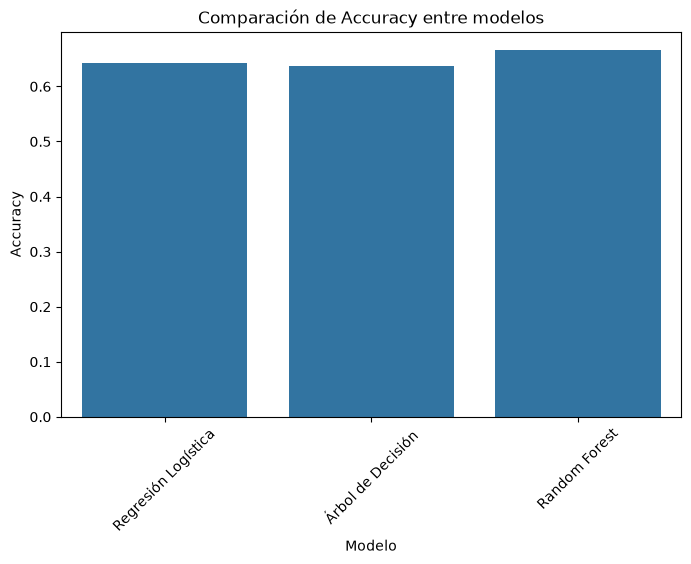

In [73]:
import matplotlib.pyplot as plt
import seaborn as sns

modelos = [
    "Regresión Logística",
    "Árbol de Decisión",
    "Random Forest"
]

accuracy = [
    accuracy_logistico,
    accuracy_arbol,
    accuracy_bosque
]

plt.figure(figsize=(8,5))

sns.barplot(
    x=modelos,
    y=accuracy
)

plt.title("Comparación de Accuracy entre modelos")
plt.ylabel("Accuracy")
plt.xlabel("Modelo")
plt.xticks(rotation=45)

plt.show()

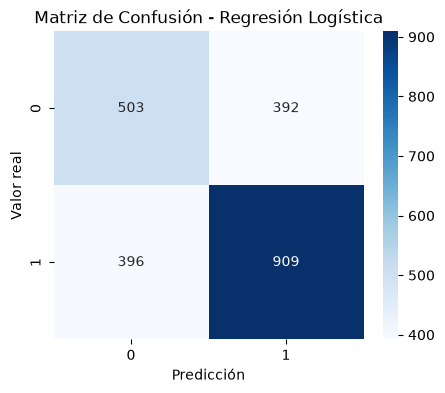

In [77]:
# Matriz de confusión Regresión Logística

cm_logistico = confusion_matrix(y_test, pred_logistico)

plt.figure(figsize=(5,4))
sns.heatmap(cm_logistico, annot=True, fmt="d", cmap="Blues")

plt.title("Matriz de Confusión - Regresión Logística")
plt.xlabel("Predicción")
plt.ylabel("Valor real")

plt.show()

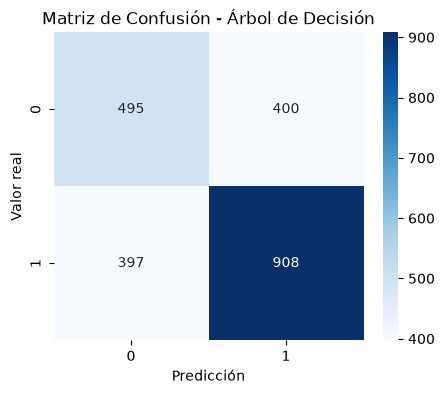

In [78]:
# Matriz de confusión Árbol de Decisión

cm_arbol = confusion_matrix(y_test, pred_arbol)

plt.figure(figsize=(5,4))
sns.heatmap(cm_arbol, annot=True, fmt="d", cmap="Blues")

plt.title("Matriz de Confusión - Árbol de Decisión")
plt.xlabel("Predicción")
plt.ylabel("Valor real")

plt.show()

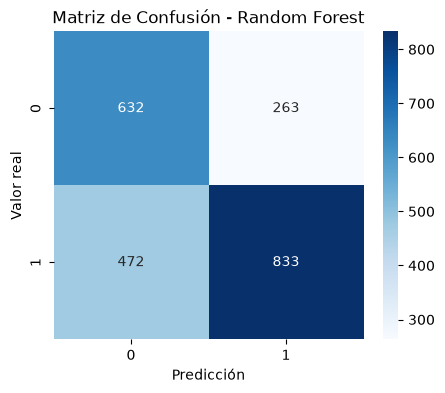

In [79]:
# Matriz de confusión Random Forest

cm_bosque = confusion_matrix(y_test, pred_bosque)

plt.figure(figsize=(5,4))
sns.heatmap(cm_bosque, annot=True, fmt="d", cmap="Blues")

plt.title("Matriz de Confusión - Random Forest")
plt.xlabel("Predicción")
plt.ylabel("Valor real")

plt.show()

| Modelo              | Aciertos totales | Accuracy |
| ------------------- | ---------------- | -------- |
| Regresión Logística | 1412             | 64.18%   |
| Árbol de Decisión   | 1403             | 63.77%   |
| Random Forest       | 1465             | 66.59%   |


### Análisis de matrices de confusión

Las matrices de confusión permitieron analizar detalladamente los aciertos y errores de cada modelo.

La Regresión Logística obtuvo 1412 clasificaciones correctas, mientras que el Árbol de Decisión obtuvo 1403.

Por su parte, Random Forest alcanzó 1465 predicciones correctas sobre 2200 registros de prueba, siendo el modelo con mejor desempeño general.

Además, Random Forest presentó una menor cantidad de falsos positivos, clasificando correctamente una mayor cantidad de envíos entregados a tiempo.

Teniendo en cuenta el Accuracy obtenido, las métricas de evaluación y el análisis de la matriz de confusión, se selecciona Random Forest como el modelo más adecuado para este problema de clasificación.